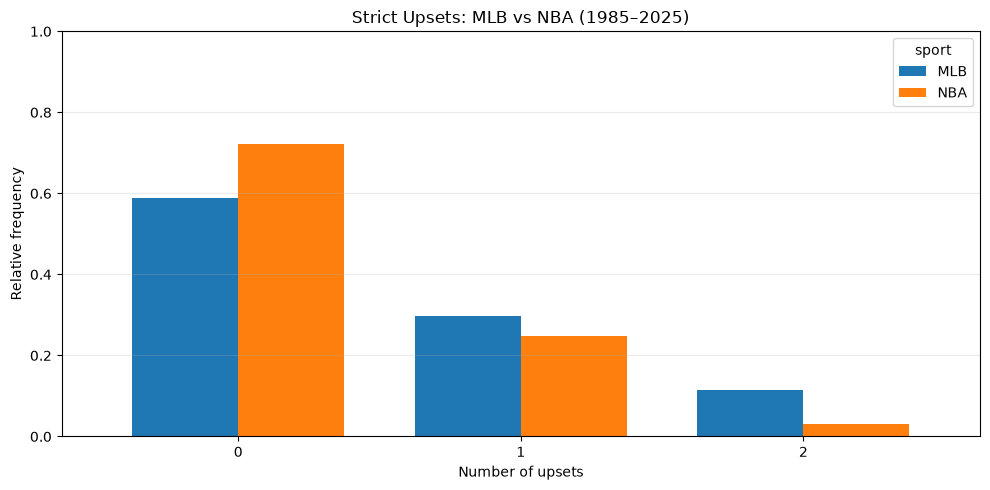

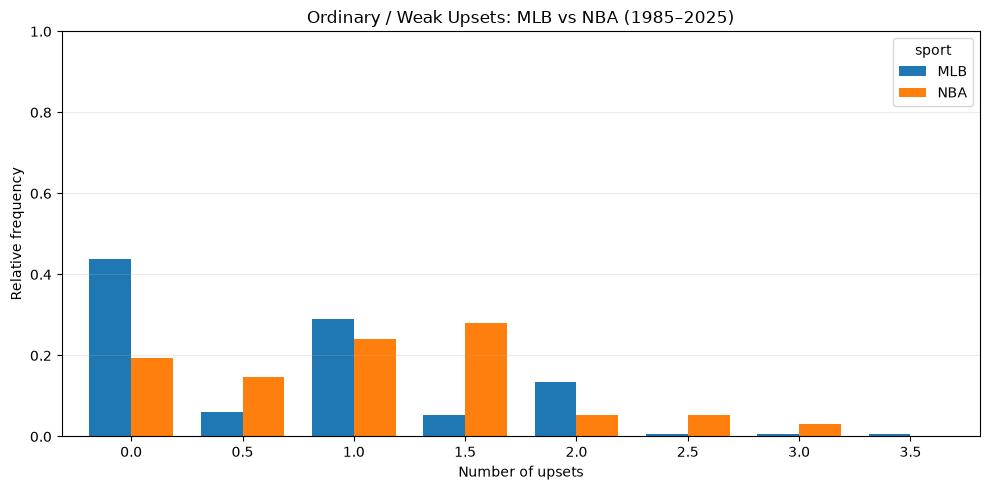

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

mlb = pd.read_csv("../Analysis/mlb_analysis.csv")
nba = pd.read_csv("../Analysis/nba_analysis.csv")

mlb["sport"] = "MLB"
nba["sport"] = "NBA"

df = pd.concat([mlb, nba], ignore_index=True)

# Only five-team divisions from 1985-2025
df = df[
    df["season"].between(1985, 2025) &
    (df["num_teams"] == 5)
].copy()

# Plot both definitions
for col, title in [
    ("upset_strict", "Strict Upsets"),
    ("upset_weak", "Ordinary / Weak Upsets")
]:
    fig, ax = plt.subplots(figsize=(10, 5))

    freq = (
        df.groupby(["sport", col])
        .size()
        .unstack("sport", fill_value=0)
        .reindex(columns=["MLB", "NBA"], fill_value=0)
    )

    # Normalize each sport independently
    freq = freq.div(freq.sum(axis=0), axis=1)

    freq.plot(kind="bar", ax=ax, width=0.75)

    ax.set_title(f"{title}: MLB vs NBA (1985–2025)")
    ax.set_xlabel("Number of upsets")
    ax.set_ylabel("Relative frequency")
    ax.tick_params(axis="x", rotation=0)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()